# 과제 1 - SVM 회귀


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_openml
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore')

In [2]:
# boston = fetch_openml(name='boston', version=1, as_frame=False)
# X, y = boston.data, boston.target

# 보스턴 데이터셋 오류로 인해, 캘리포니아 주택 가격 데이터셋으로 변경했습니다.
from sklearn.datasets import fetch_california_housing

# 데이터 로드
california = fetch_california_housing(as_frame=True)
X, y = california.data, california.target

In [3]:
# 데이터 미리보기
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [4]:
# 데이터 미리보기
y.describe()

,MedHouseVal
count,20640.000000
mean,2.068558
std,1.153956
min,0.149990
25%,1.196000
50%,1.797000
75%,2.647250
max,5.000010


In [5]:
# 훈련 및 테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
y_train # 타겟값 확인

,MedHouseVal
14196,1.030
8267,3.821
17445,1.726
14265,0.934
2271,0.965
...,...
11284,2.292
11964,0.978
5390,2.221
860,2.835


In [7]:
# 모델 생성
svr = LinearSVR(epsilon = 0.5)

# 모델 훈련
svr.fit(X_train, y_train)

LinearSVR(epsilon=0.5)

In [8]:
# 예측
y_pred = svr.predict(X_test)
y_pred

array([1.2489048 , 1.74317844, 1.81086376, ..., 3.33309519, 1.62885784,
       1.94274197])

In [9]:
# 성능 평가
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 0.7499187996145366
R-squared: 0.4277215647429158


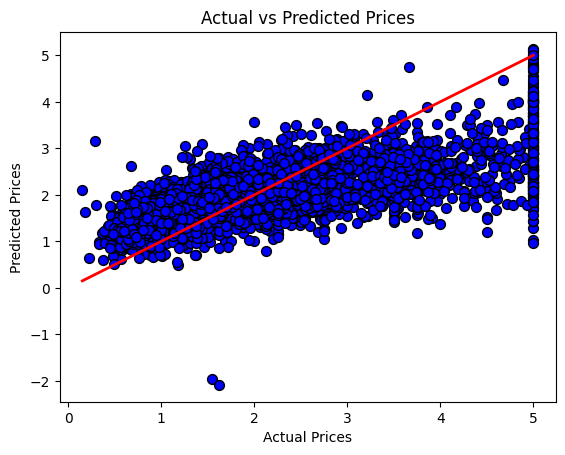

In [10]:
# 일부 feature를 사용하여 2D로 시각화
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', s=50)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linewidth=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()

## 과제 1-1 : epsilon 값을 변경하면서 LinearSVR을 적합한 후, 결과를 확인하고 이유를 분석해주세요!

성능 평가 후 평가지표와 그래프를 사용해서 분석해주세요
- epsilon은 Support Vector Regression (SVR) 모델에서 중요한 하이퍼파라미터로, 모델의 예측값과 실제 값 사이에서 허용되는 오차의 범위를 설정합니다. (= 모델이 예측에서 어느 정도까지의 차이를 무시할지를 결정하는 셈입니다)
- epsilon이 작을 때는 오차를 허용하는 정도가 작기 때문에 모델은 데이터를 더 정확히 맞추려고 합니다. (= 그 결과 더 낮은 MSE를 보입니다) 하지만, 너무 작은 epsilon 값은 데이터의 노이즈까지 학습(=오버피팅)하게 될 위험이 있습니다.
- epsilon이 클 때는 오차를 많이 허용하게 되므로 예측값이 실제값과 크게 벗어날 수 있습니다. (= 그 결과 더 큰 MSE를 보입니다) 이는 곧 모델이 데이터를 제대로 학습하지 못했다는 뜻이 됩니다.

In [11]:
# epsilon 값을 바꿔가면서 성능 평가
epsilon_values = np.linspace(0.01, 5.0, 20) # 00.1부터 5.0까지 20개를 바꿔보자
mse_scores = []
r2_scores = []

# 각 epsilon 값에 대해 모델 훈련 및 성능 평가
for epsilon in epsilon_values:
    svr = LinearSVR(epsilon=epsilon, random_state=42) # 모델 설정
    svr.fit(X_train, y_train) # 훈련 수행
    y_pred = svr.predict(X_test) # 예측 수행
    mse_scores.append(mean_squared_error(y_test, y_pred)) # 성능 측정 & 기록
    r2_scores.append(r2_score(y_test, y_pred)) # 성능 측정 & 기록

print(epsilon_values) # epsilon 값 20개 확인차 출력

[0.01       0.27263158 0.53526316 0.79789474 1.06052632 1.32315789
 1.58578947 1.84842105 2.11105263 2.37368421 2.63631579 2.89894737
 3.16157895 3.42421053 3.68684211 3.94947368 4.21210526 4.47473684
 4.73736842 5.        ]


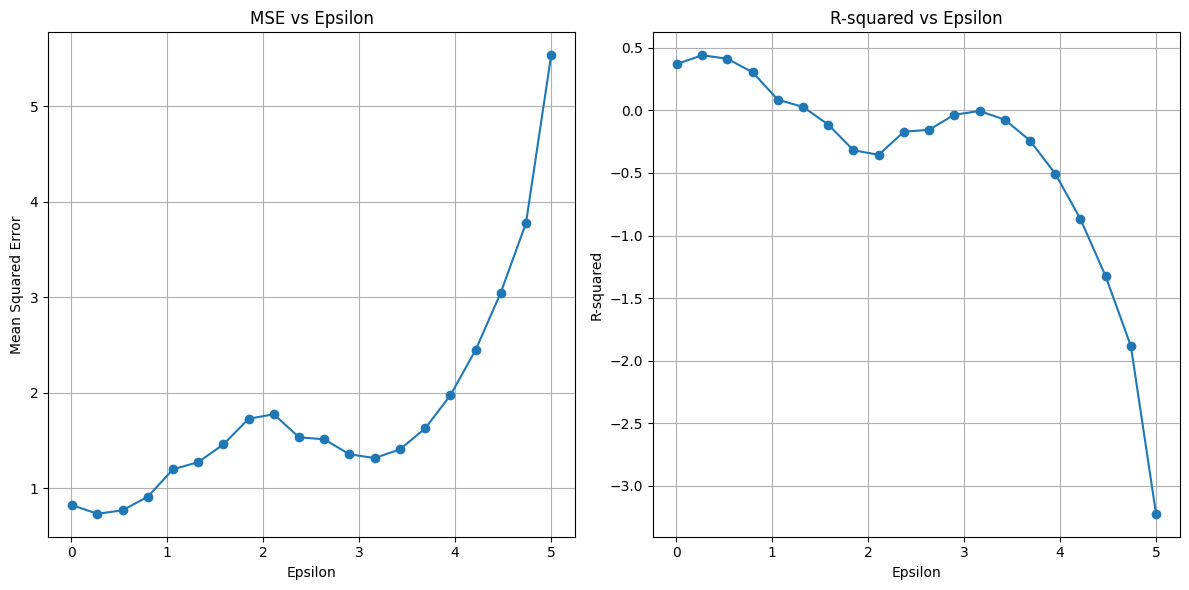

In [12]:
# 결과 시각화 (subplot 사용해서 MSE, R2을 함께 확인!)
plt.figure(figsize=(12, 6))

# MSE 시각화
plt.subplot(1, 2, 1)
plt.plot(epsilon_values, mse_scores, marker='o') # y축에 MSE
plt.title('MSE vs Epsilon')
plt.xlabel('Epsilon')
plt.ylabel('Mean Squared Error')
plt.grid()

# R-squared 시각화
plt.subplot(1, 2, 2)
plt.plot(epsilon_values, r2_scores, marker='o') # y축에 R-squared
plt.title('R-squared vs Epsilon')
plt.xlabel('Epsilon')
plt.ylabel('R-squared')
plt.grid()

plt.tight_layout()
plt.show()

# 과제 1-2 : SVM 분류

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.datasets import load_iris
import warnings

# 경고 메시지 무시
warnings.filterwarnings('ignore')

In [14]:
# 데이터 로드
iris = load_iris()
X, y = iris.data, iris.target

# 훈련 및 테스트 세트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 과제 1 - 2 trade-off 파라미터 C 값 설정

아래 수식처럼 C가 동작하는데, C가 작을수록 에러가 생겨도 가중치가 작기에 오버피팅을 막을 수 있음.

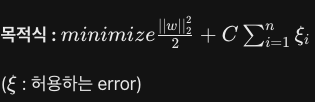


In [17]:
# 다양한 trade-off 파라미터 C 값 설정
C_values = [0.01, 0.1, 1, 10, 100, 1000] # 지수적으로 증가시키며 테스트
train_accuracies = []
test_accuracies = []

for C in C_values:
    # 모델 생성
    svc = LinearSVC(C=C)

    # 모델 훈련
    svc.fit(X_train, y_train)

    # 훈련 데이터와 테스트 데이터에 대한 예측
    y_train_pred = svc.predict(X_train)
    y_test_pred = svc.predict(X_test)

    # 정확도 계산
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # 결과 저장
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

    # 성능 출력
    print(f"C={C}:")
    print(f"Training Accuracy: {train_acc}")
    print(f"Testing Accuracy: {test_acc}")
    print(f"Classification Report:\n{classification_report(y_test, y_test_pred)}")
    print("-" * 50)


C=0.01:
Training Accuracy: 0.8
Testing Accuracy: 0.8333333333333334
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.44      0.62         9
           2       0.69      1.00      0.81        11

    accuracy                           0.83        30
   macro avg       0.90      0.81      0.81        30
weighted avg       0.89      0.83      0.82        30

--------------------------------------------------
C=0.1:
Training Accuracy: 0.9666666666666667
Testing Accuracy: 1.0
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

------

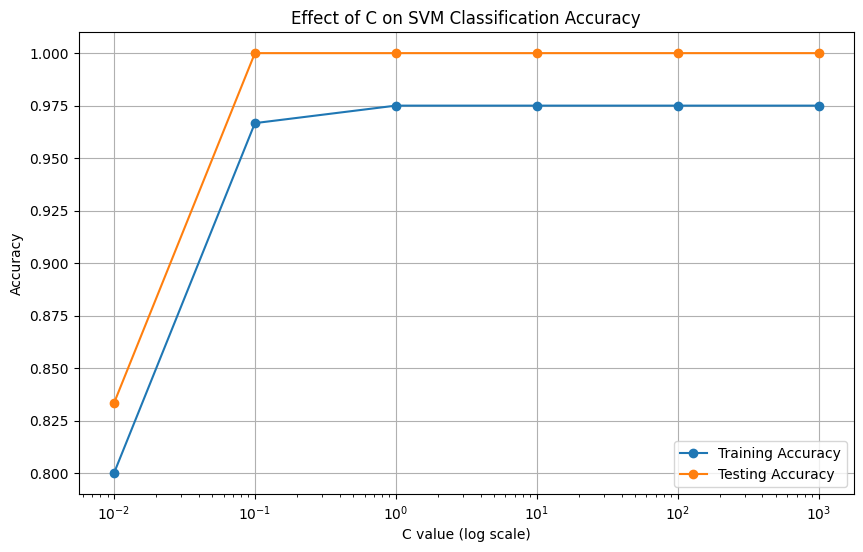

In [18]:
# C 값에 따른 정확도 시각화
plt.figure(figsize=(10, 6))
plt.plot(C_values, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(C_values, test_accuracies, marker='o', label='Testing Accuracy')
plt.xscale('log')
plt.xlabel('C value (log scale)')
plt.ylabel('Accuracy')
plt.title('Effect of C on SVM Classification Accuracy')
plt.legend()
plt.grid(True)
plt.show()